#Import Libraries

In [21]:
import pandas as pd
import numpy as np
import re
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [22]:


df = pd.read_csv("/content/drive/MyDrive/DataSet/SPAM text message 20170820 - Data.csv")


First, before training any machine learning model, we need to understand our dataset."

For example:

How many messages?
What columns?
Are there missing values?
Are there duplicate messages?
How many spam messages?
How many normal messages?

This is called Exploratory Data Analysis (EDA).

In [23]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nClass Distribution:")
print(df['Category'].value_counts())

Dataset Shape: (5572, 2)

Columns:
['Category', 'Message']

Missing Values:
Category    0
Message     0
dtype: int64

Duplicate Rows:
415

Class Distribution:
Category
ham     4825
spam     747
Name: count, dtype: int64


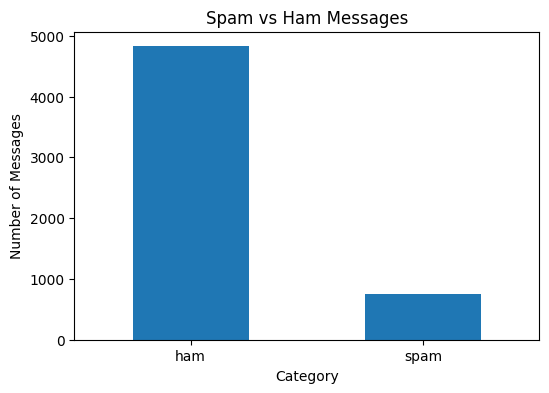

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

df['Category'].value_counts().plot(kind='bar')

plt.title("Spam vs Ham Messages")
plt.xlabel("Category")
plt.ylabel("Number of Messages")
plt.xticks(rotation=0)

plt.show()

In [25]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Dataset Information

In [26]:
df.info()
df.describe()

print(df['Category'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
Category
ham     4825
spam     747
Name: count, dtype: int64


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


#Text Cleaning

In [28]:
def clean_text(text):
    text = str(text)

    # Convert text to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

Encode Labels

In [29]:

df['Category'] = df['Category'].map({
    'ham':0,
    'spam':1
})

Split Dataset


In [30]:

X = df['Message']
y = df['Category']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

TF-IDF

In [31]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_df=0.95,
    min_df=2
)

X_train = tfidf.fit_transform(X_train)
X_test = tfidf.transform(X_test)

In [32]:
print("Number of training messages:", X_train.shape[0])
print("Number of TF-IDF features:", X_train.shape[1])

Number of training messages: 4457
Number of TF-IDF features: 3371


In [33]:
feature_names = tfidf.get_feature_names_out()

print("First 30 TF-IDF Features:")
print(feature_names[:30])

First 30 TF-IDF Features:
['00' '000' '01223585334' '02' '0207' '02073162414' '03' '04' '05' '0578'
 '06' '07' '07123456789' '07742676969' '07781482378' '07821230901'
 '07xxxxxxxxx' '0800' '08000839402' '08000930705' '08000938767'
 '08001950382' '08002986030' '08006344447' '0808' '0825' '0845'
 '08452810073' '0870' '08700621170150p']


In [34]:
print("TF-IDF Matrix Shape:")
print(X_train.shape)

TF-IDF Matrix Shape:
(4457, 3371)


# Train Model

In [35]:


model = MultinomialNB()

model.fit(X_train, y_train)


MultinomialNB()

#Prediction

In [36]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

Evaluation

In [37]:
print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9739910313901345

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       966
           1       1.00      0.81      0.89       149

    accuracy                           0.97      1115
   macro avg       0.99      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115


Confusion Matrix:

[[966   0]
 [ 29 120]]


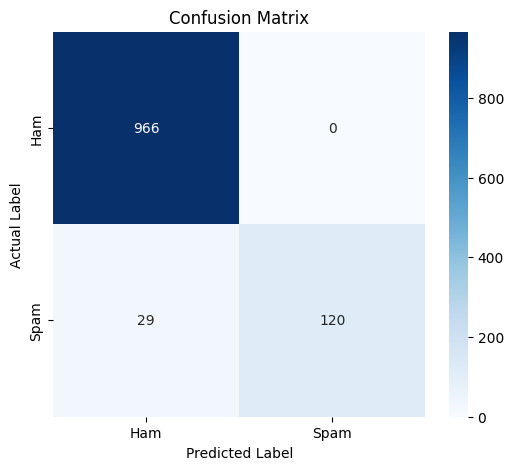

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [39]:
message = "Congratulations! You won a free prize!"
vector = tfidf.transform([clean_text(message)])

probability = model.predict_proba(vector)

print("Ham Probability :", probability[0][0])
print("Spam Probability:", probability[0][1])

Ham Probability : 0.09696769629418951
Spam Probability: 0.9030323037058098


Save Model

In [40]:
joblib.dump(model, "spam_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

Custom Prediction

In [41]:
def predict_spam(message):

    # Step 1: Clean the message
    cleaned_message = clean_text(message)

    # Step 2: Convert text into TF-IDF features
    vector = tfidf.transform([cleaned_message])

    # Step 3: Predict class
    prediction = model.predict(vector)[0]

    # Step 4: Get probability
    probability = model.predict_proba(vector)[0]

    ham_probability = probability[0]
    spam_probability = probability[1]

    # Step 5: Display result
    print("\nOriginal Message:")
    print(message)

    print("\nCleaned Message:")
    print(cleaned_message)

    print("\nPrediction:")

    if prediction == 1:
        print("🚨 SPAM")
    else:
        print("✅ HAM")

    print("\nModel Probability:")
    print(f"Ham  : {ham_probability:.2%}")
    print(f"Spam : {spam_probability:.2%}")


message = input("Enter your message: ")

predict_spam(message)

Enter your message: you got 1000 taka

Original Message:
you got 1000 taka

Cleaned Message:
you got taka

Prediction:
✅ HAM

Model Probability:
Ham  : 98.91%
Spam : 1.09%


In [42]:
feature_names = tfidf.get_feature_names_out()

spam_log_prob = model.feature_log_prob_[1]
ham_log_prob = model.feature_log_prob_[0]

spam_difference = spam_log_prob - ham_log_prob

top_spam_indices = np.argsort(spam_difference)[-20:][::-1]

print("Words most strongly associated with SPAM:\n")

for index in top_spam_indices:
    print(feature_names[index],
          "->",
          round(spam_difference[index], 3))

Words most strongly associated with SPAM:

claim -> 3.756
prize -> 3.547
150p -> 3.302
www -> 3.296
uk -> 3.182
tone -> 3.099
18 -> 3.072
guaranteed -> 3.07
1000 -> 2.978
cs -> 2.969
500 -> 2.955
landline -> 2.923
ringtone -> 2.874
16 -> 2.819
awarded -> 2.771
service -> 2.752
150ppm -> 2.746
collection -> 2.699
000 -> 2.644
dating -> 2.64


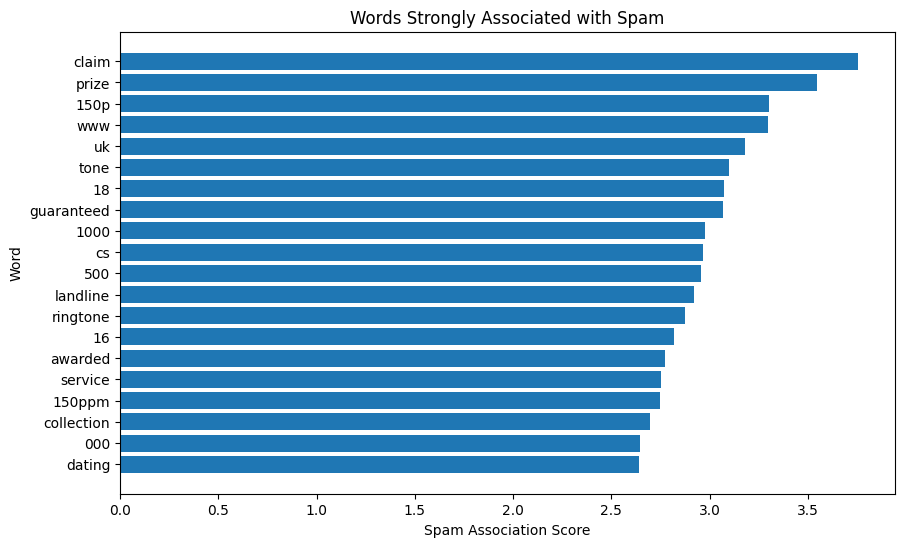

In [43]:
top_words = feature_names[top_spam_indices]
top_scores = spam_difference[top_spam_indices]

plt.figure(figsize=(10,6))

plt.barh(top_words[::-1], top_scores[::-1])

plt.xlabel("Spam Association Score")
plt.ylabel("Word")
plt.title("Words Strongly Associated with Spam")

plt.show()